# Shrink / enlarge labels or get borders

This notebook takes exisiting integer label maps and modifies them via morphological erosion or dilation by a given radius.

Additionally, it can produce the difference between original and processed labels, creating a **"ring" inside or outside of object borders**.

Instead of naive dilation, we use Watershed-based expansion to assign labels to the closest object in crowded environments (instead of the highest label in neighborhood). For shrinking, we erode object-by-object to prevent neighbors from affecting the result in crowded environments.

## Required Inputs

- a folder containing input masks as integer TIFF files

## Outputs

- a new folder with modified label maps as TIFF files (same filenames as input files). Labels stay the same.

In [ ]:
from enum import StrEnum, auto

from skimage.morphology import erosion, dilation
from skimage.measure import regionprops, label
from skimage.segmentation import watershed
import numpy as np

from calmutils.morphology.structuring_elements import hypersphere_centered


class Operation(StrEnum):
    EXPAND = auto(),
    SHRINK = auto()


def shrink_labels(labels, radius, borders_only=False):
    """
    Shrink integer labels by radius using per-object erosion
    """

    # erode labels one-by-one to prevent lower-label neighbors from flowing into others
    arr = labels.copy()
    for region in regionprops(arr):
        # erode the binary mask if this region, set to zero
        # NOTE: needs constant 0-padding to also erode at bbox edge
        eroded_mask = erosion(region.image, hypersphere_centered(labels.ndim, radius), mode='constant')
        # set remaining area to zero -> border stays labelled
        arr[region.slice][eroded_mask] = 0

    # if we only want borders, we're done
    if borders_only:
        return arr
    
    # subtract borders from original to get eroded interior
    arr = labels - arr
    return arr


def expand_labels(labels, radius, borders_only=False):
    """
    Expand integer labels by radius via Watershed.
    """

    labels_binary = labels > 0

    # got through connected components of labels one-by-one (to prevent expensive morpholgy operation on whole image)
    arr = labels.copy()
    for region in regionprops(labels):

        # expand slice of region by radius+1 pixels, clip to image dimensions
        slices_expanded = []
        shape_expanded = []
        for slice_, d in zip(region.slice, labels.shape):
            new_start = max(slice_.start - radius - 1, 0)
            new_stop = min(slice_.stop + radius + 1, d)    
            slices_expanded.append(slice(new_start, new_stop))
            shape_expanded.append(new_stop - new_start)
        slices_expanded = tuple(slices_expanded)

        # dilate binary mask in expanded region
        mask_dilated = dilation(labels_binary[slices_expanded], hypersphere_centered(labels.ndim, radius))
        
        # expand via Watershed on dummy flat zeros image
        arr[slices_expanded] = watershed(
            np.zeros(shape_expanded),
            markers=labels[slices_expanded],
            mask=mask_dilated
        )

    if not borders_only:
        return arr

    # set area of original labels to 0 -> only keep expanded mask
    arr[labels_binary] = 0
    return arr

In [ ]:
in_path = '/Volumes/nn/Julia Vogtmann/Microscopy/25JV_006'

# subfolder containing input labels
labels_subdirectory = 'segmentation_nuclei'
# where to save results to
out_subdirectory = 'segmentation_nuclei_border'

# what to do: 'expand' or 'shrink'
operation = 'expand'
# radius of operation
radius = 7
# whether to return only border or whole modified labels
border_only = True

In [ ]:
from pathlib import Path
from natsort import natsorted

# check that we selected expand or shrink
if operation not in Operation:
    raise ValueError(f'Undefined operation {operation}, available options: {set(Operation)}')

in_files = natsorted((Path(in_path) / labels_subdirectory).glob('[!.]*.tif'))
in_files

In [ ]:
from skimage.io import imread
from io_helpers import imsave_nowarnings

# make out directory if it doesn't exist already
out_path = Path(in_path) / out_subdirectory
if not out_path.exists():
    out_path.mkdir()

for in_file in in_files:

    # load
    labels = imread(in_file)

    # apply either expansion or shrinking
    labels_modified = expand_labels(labels, radius, border_only) if operation == Operation.EXPAND else shrink_labels(labels, radius, border_only)

    # save to output folder with same name
    out_file = out_path / in_file.name
    imsave_nowarnings(out_file, labels_modified)
    
    print(f'{in_file} done.')

## TESTING code below -> commented out for papermill usage

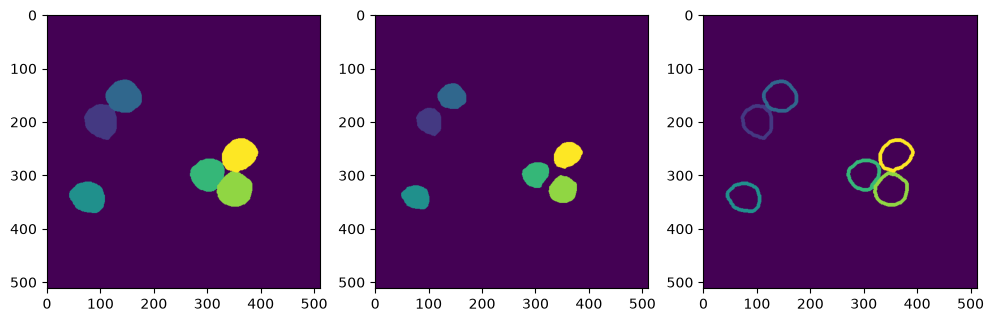

In [14]:
# from matplotlib import pyplot as plt
# from skimage.io import imread

# labels = imread('test_labels.tif')
# labels_shrink_inner = shrink_labels(labels, 7, borders_only=False)
# labels_shrink_border = shrink_labels(labels, 7, borders_only=True)

# fig, axs = plt.subplots(ncols=3, figsize=(12,4))
# axs[0].imshow(labels)
# axs[1].imshow(labels_shrink_inner)
# axs[2].imshow(labels_shrink_border)

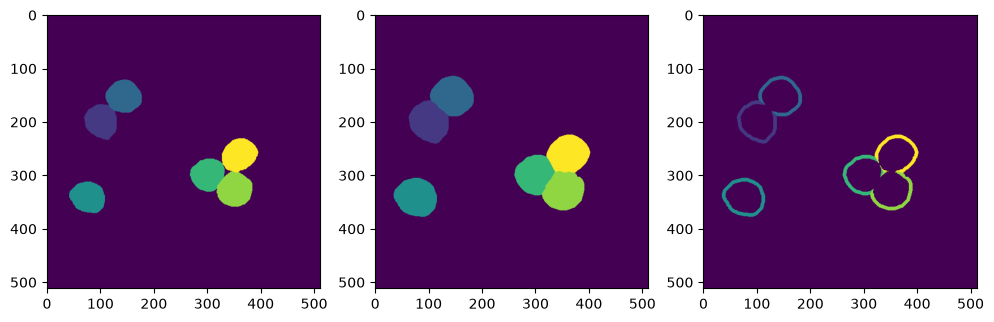

In [15]:
# labels = imread('test_labels.tif')
# labels_expand_inner = expand_labels(labels, 7, borders_only=False)
# labels_expand_border = expand_labels(labels, 7, borders_only=True)

# fig, axs = plt.subplots(ncols=3, figsize=(12,4))
# axs[0].imshow(labels)
# axs[1].imshow(labels_expand_inner)
# axs[2].imshow(labels_expand_border)

In [ ]:
# import napari

# if napari.current_viewer() is not None:
#     napari.current_viewer().close()

# viewer = napari.Viewer()

# viewer.add_labels(labels_expand_border)